In [1]:
# %pip install -U google-generativeai
# %pip install google-ai-generativelanguage==0.6.15
# %pip install -U langchain-google-genai
# %pip install -U langchain-community
# %pip install -U langgraph
# %pip install -U langgraph langchain-community
# %pip install python-dotenv


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgr

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

from langchain_community.tools.tavily_search import TavilySearchResults

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

os.getenv('GEMINI_API_KEY')
os.getenv('TAVILY_API_KEY')

'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'

In [6]:
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


### Definição do estado do agente

In [7]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
# class AgentState(TypedDict):
#   messages: Annotated[Sequence[BaseMassage], operator.add]


In [11]:
class AgentState(TypedDict):
  input: str
  chat_history: list[BaseMessage]
  agent_outcome: Union[AgentAction, AgentFinish, None]
  intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]


NameError: name 'BaseMessage' is not defined

### Definição do agente

In [8]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [9]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

abot = Agent(model, [tool], system=prompt)

In [10]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### Gera a visualização do agente em formato gráfico

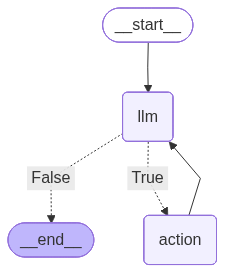

In [11]:
from IPython.display import Image, display

try:
    
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))

except Exception as e:
    print(f"Erro ao tentar gerar PNG do Mermaid: {e}")
    print("\nCertifique-se de que a sua versão do LangGraph possui o método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obter a string e visualizar externamente.")

In [17]:
# %pip install -U langchain-tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-tavily]
Note: you may need to restart the kernel to use updated packages.


In [12]:
from langchain_core.messages import BaseMessage


class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t_call in tool_calls:
            print(f"Calling tool: {t_call['name']} with args: {t_call['args']}")
            if t_call['name'] not in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t_call['name']].invoke(t_call['args'])
            results.append(ToolMessage(tool_call_id=t_call['id'], name=t_call['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [21]:
# %pip install tavily-python

  Using cached tiktoken-0.12.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (6.7 kB)
  Using cached regex-2026.2.28-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
Using cached tiktoken-0.12.0-cp313-cp313-manylinux_2_28_x86_64.whl (1.2 MB)
Using cached regex-2026.2.28-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (802 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [tavily-python]0m [tavily-python]
Note: you may need to restart the kernel to use updated packages.


In [13]:
from langchain_tavily import TavilySearch

prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""
model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearch(max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)

messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]

print("Iniciando interação do agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"topic": "news", "query": "tempo em S\\u00e3o Paulo hoje"}'}, '__gemini_function_call_thought_signatures__': {'746b5349-3416-4045-adce-bcfcd0466af6': 'Cs8CAb4+9vurVUrYtF1DCbEAKBXrLs6LX64X6o4Uu0khksLvDcd3PwuAqnMujo3E/G9svwMNQbFGXNebXKxNwxoSkzEwmxybq2ji95uEpcgpvo+TZuxfOPR7paDT8jJ40c+y9Q0lIvqIrH4YT6D9vIFtmaimPsi6mjQmwp3Cxo5fRo7XeOJIhkLk83OMtXMbmFnf1UeoEk8dUX1GFBhqsM9VEGmh6pxH+yWSeSLIFTnn9DSi9OV8GxhrkLyRoK5H7UDn+tRHnfp824sPToc2ZeiznSrEUNcW6G3hsIqSIirM2lHCct3uGIX4XofPwLMt2yEfocgdVlxCuQrcZEW/mfv9H/oHIyH5aiL+0bsJCnSbIiz0JHIvBdC4a29U6AT5XygnK4e/M6MzedvSrd9CfbJxcB7ixnaM5XPsWxxssRiQ2dM9qRvTqrjE3T7rYpnprp4='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2c64-827a-7e53-a8a7-c46dd921e6a1-0', tool_calls=[{'name': 'tavily_search', 'args': {'topi

In [14]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y") # Formato dd/mm/aaaa

prompt = f"""Você é um assistente de pesquisa inteligente e altamente atualizado. \
Sua principal prioridade é encontrar as informações mais RECENTES e em TEMPO REAL sempre que possível. \
A data atual é {current_date}. \
Ao buscar sobre o tempo ou eventos que se referem a "hoje" ou "agora", \
você DEVE **incluir a data atual '{current_date}' na sua consulta para a ferramenta de busca**. \
Por exemplo, se a pergunta é "tempo em cidade x hoje", a consulta para a ferramenta deve ser "tempo em cidade x {current_date}". \
Ignore ou descarte informações que claramente se refiram a datas passadas ou futuras ao responder perguntas sobre "hoje". \
Use o mecanismo de busca para procurar informações, sempre buscando o 'hoje' ou o 'agora' quando o contexto indicar. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
""" 

model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearch(max_results=4)
abot = Agent(model_instance, [tool_instance], system=prompt)

user_query = "Como está o tempo em São Paulo hoje?"

messages = [HumanMessage(content=user_query)]

print("Iniciando interação do agente:")
final_result_state = None
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em S\\u00e3o Paulo 26/03/2026", "search_depth": "basic"}'}, '__gemini_function_call_thought_signatures__': {'33d1a578-c617-492c-b67a-21af0c46e2b0': 'CrECAb4+9vugzvAvgr7b05aOF8pntD21lPJntyRGZKHoXWZzq9nQJgnBJ++yALlFDUz/XnpnB4MszuMS/ZV8bCnL0ErFnYtfO9fWQOs7D/SGv3V+TcY5Gc08Pxb+tInQSTPMW2DMiLChlxWunuft+bGSxilV1Z9F3CiYeduqCTX1lz7Rwpl7hfKsoSaHPrvkpqJzYdtm6cvTk7sliwFYgsUE30s0vbeZCtAsWsH0MGwtzI8eEX9xjq8Ar71lrMZTie2llrhMbE+0fQt8q4wo0Oac/IkLSWOFl7DkYcvUrLSvwjgi8re2NQP2FzNhAj+ccQmtxcjPCqbSPG6lBDD00Ln8FwY+j5zz62jHhvstoQqDiTQ7P23cAYU5vGMbezQcS8WTU3ornwCMnZqFVlWFuOsxD24='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2c64-e90e-7343-8e66-22535d505aee-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'tempo em São Paulo 26

In [16]:

user_query_tomorrow = "Como está o tempo em Mogi das Cruzes amanhã?" #atualizamos apenas a pergunta do usuário

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente para amanhã ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para amanhã ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado para amanhã.")


--- Iniciando interação do agente para amanhã ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em Mogi das Cruzes 27/03/2026"}'}, '__gemini_function_call_thought_signatures__': {'731b2e7a-f485-4f25-8d21-80b48f8710b2': 'Cq8CAb4+9vvZ9UkoL87oeFlbTTI/8wuQJ7+6jYv4Xdq8LreXal7U4WLq5UXwP/AEZ7bFP9Ar+VK4nYjDnyzOHDmbveibBEkGjGu9pfuNA8mqKPbD5eR9DBR2HlwHH+SZW7p8PNJdGhuJNwNp5P3txetS8Y8pXJK8CED9hNS/TFsX48Gsym7eVr16EpK07D30PkdLPySpEx89r/Ear12pCaR4j/1pJWPpeb4Q8N3/t4kJZJEGr7p/qoKyI69ycxsNgVwPRivARDT5O29x7E/11XBtTkgviyu0QyOuVWOEU74b67YKtN05c6qnsCxeYk2hvRiHWQTKfuQBfDMsQkoOIXzNWZ5uq4de2EZixa6vNOyPqEwfsosfJWd09SZVsN4pbo0zGe/69UsK1/wWMK+qVgEK'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2c65-7f6e-7863-9ca2-bae80b0c6a96-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'tempo em Mogi das Cruzes 27/03

In [17]:
from langchain_core.messages import HumanMessage

user_query_tomorrow = "Como foi o tempo em São Paulo ontem?" 

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final  ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")


--- Iniciando interação do agente ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em S\\u00e3o Paulo 25/03/2026"}'}, '__gemini_function_call_thought_signatures__': {'d2660aad-8a15-4589-a09b-b948be2a1db7': 'CpUCAb4+9vvHWvF+aXf+rdf6dlIBrfyN/nHBDflVXaLBxB0/muEpt8xU1KW6C7RGWsdDd0bXJGyln3M8VuOKbzbL2mgB851VoQrfknYXfavVIkSxPWd8U8GDTPPd3Rrpe7jGBiBzVN3hZ7CzvLn0eMrYpC2xLi9agYZuQkY8jNCpF9sYTO/l5WR20HACSTqRQJaUMKz8hYXxdQuCMOXZ+Kuf7Jo+2Kj0JXBZWkwkKbP6fZInR3XjkeXUjDspOw1L42MaJfHdipQ7gFenlTgY5PpexMB6BLGgKee5R/G72qlgOqHJlnY2TW7T82VKTpwwT9/ERTENJ3KOMehJLp+OV2P8Z3pE6qtCjUtmz82YT1qjWUnmmRcMMg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2c68-8bb8-79d3-966a-23c618b9319b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'tempo em São Paulo 25/03/2026'}, 'id': 'd2660aad-8a15-4589-a09b-b948be2a1d

Então, vamos chamar novamente este agente, perguntando: "Qual é o tempo em SP hoje? Dessa vez, vamos olhar em detalhes o que o agente buscou e como ele o fez.

In [18]:
messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")] 
result = abot.graph.invoke({"messages": messages}) 

Calling tool: tavily_search with args: {'query': 'tempo em São Paulo 26/03/2026'}
Back to the model!


In [19]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Em São Paulo, hoje, 26/03/2026, as temperaturas começaram a madrugada em torno de 17°C, com previsão de atingir cerca de 28°C durante o dia. Espera-se pancadas de chuva isoladas entre o meio e o fim da tarde, com possibilidade de chuva intensa (30-60 mm/h ou 50-100 mm/dia), ventos fortes (60-100 km/h) e queda de granizo. A umidade está em 43% e a nebulosidade em 15%. O nascer do sol foi às 06h03.',
  'extras': {'signature': 'Co0HAb4+9vuGkjiCtTGmkY6NFqcssQpg+tEUqaWcr0g6mTpVkMtAGqx61i/Fl0dSD/lBu9hp3QUlm/XuONDtvV7yYrXt3sEGLhUvTdaEv9a2qccAXwHsWOZoOKO4Xf46QBrmybgTs9FigTQnuisHjw1FZC9lvCHs+GEY0UQ3gd99XjSHeHMXxcGbaikMAD6EiLY4ux909N/zVJpn+F0EVgftZbwv0Ov6z64MuYad3eTdrS84xq5NqAAKZWJM3j0Ouu+4rQZ2m2e8cj8oS03ImaPj0CXg6fP8Ee9H6hw3gB7h+tcpXcDPqDm84ZxOPpnmpvYR59f7pTzdtvKCDWdGrfTQ1OjNGklN6zEOaP8tYSe6HbO+jd9UXtvWXhtenO1Skc5PwBbu/mEiUULBY8mcxz42TaFXccQlGTNNEVP2j3R1jxS0Ci2zfqDhWnQSn60/AxyqHqTj4l5U7QMtqUXx/KP3FzUdNJzrorDJ4yc9HgoErMM41RyRvCya5Zicr89FGcOKEPmEiOecqNgp6FETAaBM5fYtG/

In [27]:
messages = [HumanMessage(content="Como está o tempo em Mogi das Cruzes, São Paulo e no Rio de Janeiro hoje?")]
result = abot.graph.invoke({"messages": messages})

Calling tool: tavily_search with args: {'query': 'tempo em Mogi das Cruzes 26/03/2026'}
Calling tool: tavily_search with args: {'query': 'tempo em São Paulo 26/03/2026'}
Calling tool: tavily_search with args: {'query': 'tempo no Rio de Janeiro 26/03/2026'}
Back to the model!


In [33]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Aqui está a previsão do tempo para hoje, 26/03/2026:\n\n*   **Mogi das Cruzes, São Paulo:** A madrugada começou com temperaturas agradáveis em torno de 14°C. O dia deve ter muitas nuvens, com temperaturas variando entre 16°C e 29°C, e sem previsão de chuva significativa.\n\n*   **São Paulo:** A madrugada começou com temperaturas agradáveis em torno de 17°C. A previsão indica temperaturas elevadas, em torno de 28°C, com pancadas isoladas de chuva rápida entre a tarde e o fim da tarde.\n\n*   **Rio de Janeiro:** A madrugada começou com temperaturas agradáveis em torno de 21°C. A previsão indica temperaturas em torno de 29°C, com pancadas isoladas de chuva.',
  'extras': {'signature': 'CtIFAb4+9vuu/TS6lmuwCIEXv9aFl0hraZaNe7ywoPz9DbXb3tdT1AZMU+Li5LS1yMet/cKlnnZxfbWpho/tP+3OUo2A3HHa0K5xE48oZ1jO2zVEJN81oDbfq8jOp93rxDE1uIAolbLMFuUf+geax99lV4UJBbNSrnFK38Ch3kfgjXNIZbM06VEmegqaO30A0nZyvgSZL2SNz4TcN94FGQ/U9YDRe8bGNApwCfJCm4WcNdsb+CDk4glDK4TTI+oNgTIM8h+ZfWTklD98AcCvOoo

In [42]:
query_passado = "Qual país sediou a Copa do Mundo de futebol em 1998? Quem foi o campeão e qual o placar da final? \
Qual era o Produto Interno Bruto (PIB) desse país no ano da Copa e qual é o PIB atual (últimos dados disponíveis, como 2023 ou 2024)? \
Qual a capital desse país e qual sua moeda atual? Responda a cada pergunta separadamente."
messages = [HumanMessage(content=query_passado)]

print("\nIniciando interação do agente para pergunta sobre o passado:")

current_state = {}
for s in abot.graph.stream({"messages": messages}):
    current_state.update(s)
    print(s)
    print("---")

print("\n--- Resultado Final para o Passado ---")
if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
    final_message_content = current_state['llm']['messages'][-1]
    print(final_message_content.content[-1]['text'])
else:
    print("Nenhum resultado final ou resultado inesperado. Verifique os logs acima.")



Iniciando interação do agente para pergunta sobre o passado:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "Copa do Mundo de futebol 1998 sede"}'}, '__gemini_function_call_thought_signatures__': {'d2b34adf-e104-46fa-9162-6c9aac750d4a': 'CoUGAb4+9vu5bYXmn5jaoqxETAwxHYMa6GPsAeU63glm9wwSg+tYbddThOqUiRYgneAp5F7Qy+B4RTrpDOnGF0RKq89vz9Ba8BTAqBH1hZS89UvL+iftbWVWD+79STXp3cVMwva6jij2KU2ZOdXi6gjf5UF84ovmlb81dNF/3eKLyF8mpEGzMQYL+PeiAG0mzEgJHgDjy7kkqT6sDL/zGdpPET4QuJqOmBNNdwXXbnzVzcR1eOkr9eDuKe5kSucbAU/knvAHp5PtAS9PIEBMnDBRU+3MY2i56EVppgSYFOlk11CGcOXDmXahcmlRiEYy81vf/zg92y3cf2PqGlewyGmepzazQPoETkF5CA1eXUCFpnakR2GWg/KhzAPVKUPg7PnBgD24LZbDPoKACBA2Me1Viitn/wQrSaAubZM7dBAEGHc669fHXbTn5zirocrK4bSWBPVlh304eahRYNlIdWbokkTc9hw/XHqluFxufY4cglXdHxUTItv7HvjSz7mUxvD/+mDo2236jiU9iRP5bEBxemCJQZQcLEJtoBm/1wb6Youfa5qKaaWtcnO/x/1Ssax66TytqWec0WMFf6QIPlPsZofjAqch6gghtTIIbElefSw5+mxXb3umk5Zy6J9KSoTbnO2ny3vINuNoTt6hISRQG+SdZamh1411vI

In [44]:
print("\n--- Agente de Pesquisa Interativo ---")
print("Digite sua pergunta ou 'sair' para encerrar.")

while True:
    user_input = input("\nVocê: ") 
    if user_input.lower() == "sair":
        print("Agente: Encerrando a conversa. Até logo!")
        break

    messages = [HumanMessage(content=user_input)]

    print("Agente: Pensando e buscando...")
    final_result_state = None
    try:

        current_state = {}
        for s in abot.graph.stream({"messages": messages}):
            current_state.update(s)

        print("\nAgente:")

        if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
            final_message = current_state['llm']['messages'][-1]
            if hasattr(final_message, 'content'):
                print(final_message.content[0]['text'])
            else:
                print("Não foi possível extrair o conteúdo da resposta final do LLM.")
        else:
            print("Não foi possível obter uma resposta do agente para esta pergunta.")

    except Exception as e:
        print(f"Agente: Ocorreu um erro durante a execução: {e}")
        print("Tente novamente ou digite 'sair'.")

print("\n--- Conversa Encerrada ---")


--- Agente de Pesquisa Interativo ---
Digite sua pergunta ou 'sair' para encerrar.
Agente: Pensando e buscando...
Calling tool: tavily_search with args: {'search_depth': 'basic', 'query': 'salário mínimo Brasil 2026'}
Back to the model!
Calling tool: tavily_search with args: {'query': 'preços cesta básica Mogi das Cruzes 26/03/2026', 'search_depth': 'basic'}
Calling tool: tavily_search with args: {'query': 'preços materiais de limpeza Mogi das Cruzes 26/03/2026', 'search_depth': 'basic'}
Back to the model!
Calling tool: tavily_search with args: {'query': 'custo de vida Mogi das Cruzes 2026', 'search_depth': 'basic'}
Back to the model!
Calling tool: tavily_search with args: {'search_depth': 'basic', 'query': 'programas sociais Mogi das Cruzes 2026'}
Calling tool: tavily_search with args: {'query': 'supermercados atacado Mogi das Cruzes 2026', 'search_depth': 'basic'}
Calling tool: tavily_search with args: {'query': 'descontos e promoções supermercados Mogi das Cruzes 26/03/2026', 'sear